# Milestone 1: Data Representation & Foundations
**Project:** Public Health Data Visualization System  
**Dataset:** Global Health Statistics (1,000,000 records)  
**Objective:** Dataset acquisition, schema definition, descriptive statistics, and initial visual outputs.

## 1. Dataset Acquisition

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Resolve paths relative to project root
PROJECT_ROOT = Path().resolve().parent if Path().resolve().name == 'notebooks' else Path().resolve()
RAW_DATA = PROJECT_ROOT / 'data' / 'raw' / 'Global Health Statistics.csv'
CHARTS_DIR = PROJECT_ROOT / 'docs' / 'charts'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Python: {sys.version}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {RAW_DATA}")
print(f"Dataset exists: {RAW_DATA.exists()}")

Python: 3.12.3 (main, Mar  3 2026, 12:15:18) [GCC 13.3.0]
Project root: /home/mendarrr/Projects/Data Science/Python/Data-Visualization-Project
Dataset path: /home/mendarrr/Projects/Data Science/Python/Data-Visualization-Project/data/raw/Global Health Statistics.csv
Dataset exists: True


In [2]:
df = pd.read_csv(RAW_DATA)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Shape: 1,000,000 rows × 22 columns


,Country,Year,Disease Name,Disease Category,Prevalence Rate (%),Incidence Rate (%),Mortality Rate (%),Age Group,Gender,Population Affected,...,Hospital Beds per 1000,Treatment Type,Average Treatment Cost (USD),Availability of Vaccines/Treatment,Recovery Rate (%),DALYs,Improvement in 5 Years (%),Per Capita Income (USD),Education Index,Urbanization Rate (%)
0,Italy,2013,Malaria,Respiratory,0.95,1.55,8.42,0-18,Male,471007,...,7.58,Medication,21064,No,91.82,4493,2.16,16886,0.79,86.02
1,France,2002,Ebola,Parasitic,12.46,8.63,8.75,61+,Male,634318,...,5.11,Surgery,47851,Yes,76.65,2366,4.82,80639,0.74,45.52
2,Turkey,2015,COVID-19,Genetic,0.91,2.35,6.22,36-60,Male,154878,...,3.49,Vaccination,27834,Yes,98.55,41,5.81,12245,0.41,40.20
3,Indonesia,2011,Parkinson's Disease,Autoimmune,4.68,6.29,3.99,0-18,Other,446224,...,8.44,Surgery,144,Yes,67.35,3201,2.22,49336,0.49,58.47
4,Italy,2013,Tuberculosis,Genetic,0.83,13.59,7.01,61+,Male,472908,...,5.90,Medication,8908,Yes,50.06,2832,6.93,47701,0.50,48.14


## 2. Data Schema & Variable Definitions

In [3]:
schema = pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.values,
    'Non-Null Count': df.notnull().sum().values,
    'Null Count': df.isnull().sum().values,
    'Null %': (df.isnull().mean() * 100).round(2).values,
    'Sample Value': [df[col].dropna().iloc[0] if df[col].notnull().any() else 'N/A' for col in df.columns]
})
schema

,Column,Dtype,Non-Null Count,Null Count,Null %,Sample Value
0,Country,object,1000000,0,0.0,Italy
1,Year,int64,1000000,0,0.0,2013
2,Disease Name,object,1000000,0,0.0,Malaria
3,Disease Category,object,1000000,0,0.0,Respiratory
4,Prevalence Rate (%),float64,1000000,0,0.0,0.95
5,Incidence Rate (%),float64,1000000,0,0.0,1.55
6,Mortality Rate (%),float64,1000000,0,0.0,8.42
7,Age Group,object,1000000,0,0.0,0-18
8,Gender,object,1000000,0,0.0,Male
9,Population Affected,int64,1000000,0,0.0,471007


In [4]:
# Variable type classification

## 3. Basic Descriptive Statistics

In [4]:
# Descriptive statistics for numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns
df[numerical_cols].describe()

,Year,Prevalence Rate (%),Incidence Rate (%),Mortality Rate (%),Population Affected,Healthcare Access (%),Doctors per 1000,Hospital Beds per 1000,Average Treatment Cost (USD),Recovery Rate (%),DALYs,Improvement in 5 Years (%),Per Capita Income (USD),Education Index,Urbanization Rate (%)
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,2011.996999,10.047992,7.555005,5.049919,500735.427363,74.987835,2.747929,5.245931,25010.313665,74.496934,2499.144809,5.002593,50311.099835,0.650069,54.985212
std,7.217287,5.740189,4.298947,2.859427,288660.116648,14.436345,1.299067,2.742865,14402.279227,14.155168,1443.923798,2.888298,28726.959359,0.144472,20.214042
min,2000.000000,0.100000,0.100000,0.100000,1000.000000,50.000000,0.500000,0.500000,100.000000,50.000000,1.000000,0.000000,500.000000,0.400000,20.000000
25%,2006.000000,5.090000,3.840000,2.580000,250491.250000,62.470000,1.620000,2.870000,12538.000000,62.220000,1245.000000,2.500000,25457.000000,0.530000,37.470000
50%,2012.000000,10.040000,7.550000,5.050000,501041.000000,75.000000,2.750000,5.240000,24980.000000,74.470000,2499.000000,5.000000,50372.000000,0.650000,54.980000
75%,2018.000000,15.010000,11.280000,7.530000,750782.000000,87.490000,3.870000,7.620000,37493.000000,86.780000,3750.000000,7.510000,75195.000000,0.780000,72.510000
max,2024.000000,20.000000,15.000000,10.000000,1000000.000000,100.000000,5.000000,10.000000,50000.000000,99.000000,5000.000000,10.000000,100000.000000,0.900000,90.000000


In [5]:
# Distribution of categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols[:5]:  # First 5 categorical columns
    print(f"\n{col}:")
    print(df[col].value_counts().head())


Country:
Country
Russia          50532
South Africa    50408
South Korea     50181
Germany         50176
UK              50125
Name: count, dtype: int64

Disease Name:
Disease Name
COVID-19    50404
Zika        50313
Dengue      50289
Cancer      50285
HIV/AIDS    50274
Name: count, dtype: int64

Disease Category:
Disease Category
Metabolic       91332
Parasitic       91178
Genetic         91153
Autoimmune      91153
Neurological    91000
Name: count, dtype: int64

Age Group:
Age Group
19-35    251201
61+      249989
0-18     249605
36-60    249205
Name: count, dtype: int64

Gender:
Gender
Male      333676
Female    333223
Other     333101
Name: count, dtype: int64


In [6]:
# Year range and country coverage Outputs
# Year range
print(f"Year Range: {df['Year'].min()} - {df['Year'].max()}")

# Country coverage
print(f"\nNumber of Countries: {df['Country'].nunique()}")
print(f"\nFirst 10 Countries:")
print(df['Country'].unique()[:10])

Year Range: 2000 - 2024

Number of Countries: 20

First 10 Countries:
['Italy' 'France' 'Turkey' 'Indonesia' 'Saudi Arabia' 'USA' 'Nigeria'
 'Australia' 'Canada' 'Mexico']


## 4. Data Quality Assessment

In [7]:
# Missing Values Check
print("=" * 50)
print("MISSING VALUES CHECK")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
missing_df[missing_df['Missing Count'] > 0]

# Duplicity Check
print("\n" + "=" * 50)
print("DUPLICATE ROWS CHECK")
print("=" * 50)
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates} ({duplicates/len(df)*100:.2f}%)")

# Outliers Check (using IQR method)
print("\n" + "=" * 50)
print("OUTLIERS CHECK (Numerical Columns)")
print("=" * 50)
for col in numerical_cols[:5]:  # Check first 5 numerical columns
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
    print(f"{col}: {outliers} outliers ({outliers/len(df)*100:.2f}%)")

MISSING VALUES CHECK

DUPLICATE ROWS CHECK
Duplicate rows: 0 (0.00%)

OUTLIERS CHECK (Numerical Columns)
Year: 0 outliers (0.00%)
Prevalence Rate (%): 0 outliers (0.00%)
Incidence Rate (%): 0 outliers (0.00%)
Mortality Rate (%): 0 outliers (0.00%)
Population Affected: 0 outliers (0.00%)


## 5. Initial Visual Outputs

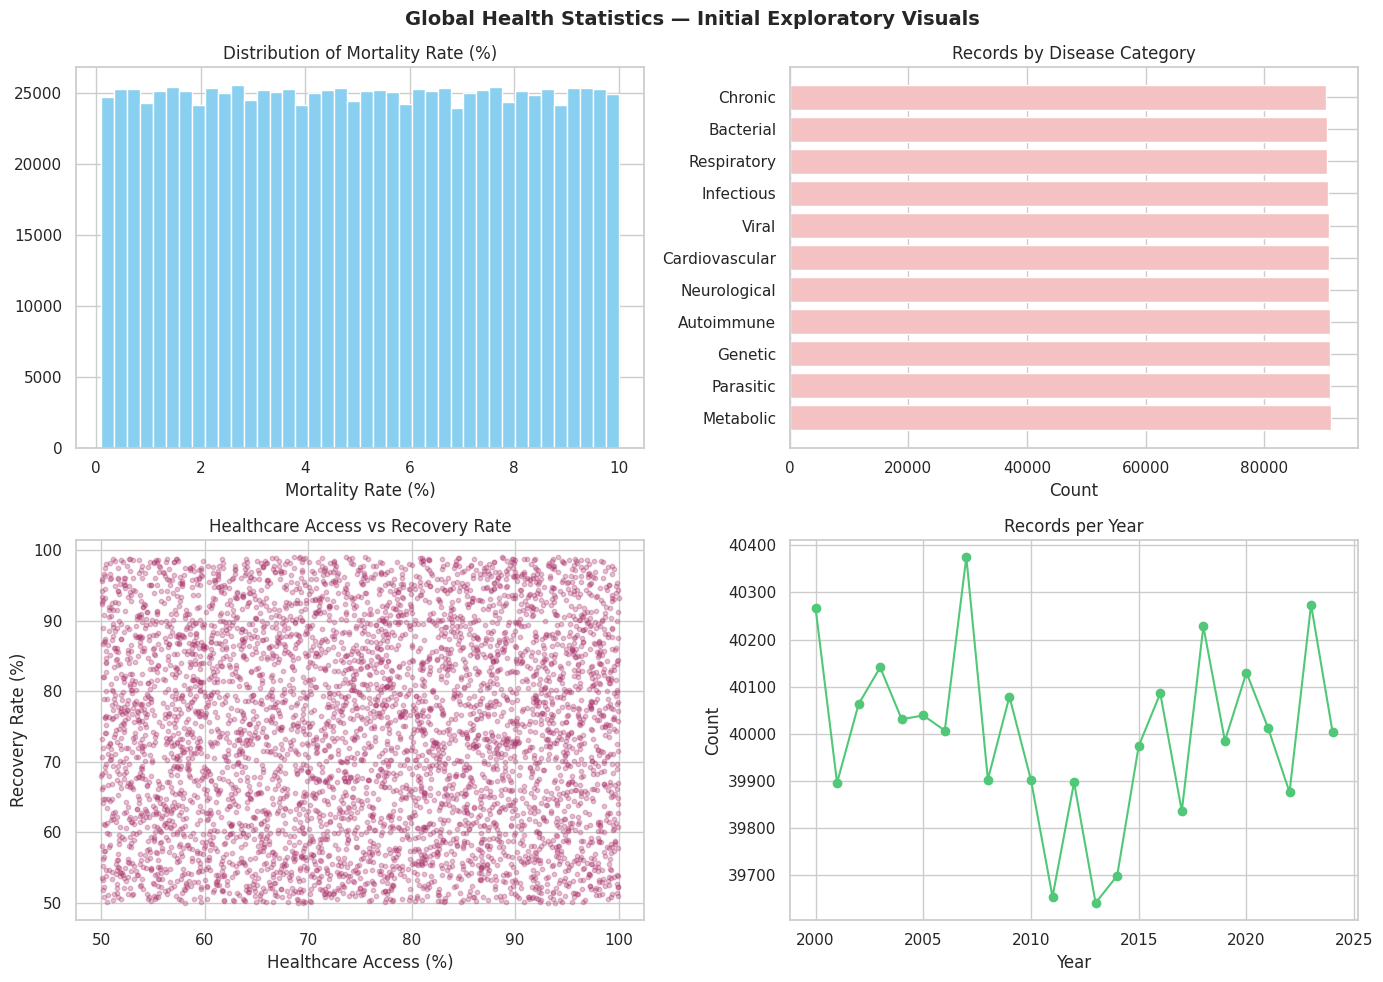

Chart saved to /home/mendarrr/Projects/Data Science/Python/Data-Visualization-Project/docs/charts/milestone1_initial_visuals.png


In [8]:
# Setting up the Theme styles for the Initial visuals
sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Global Health Statistics — Initial Exploratory Visuals', fontsize=14, fontweight='bold')

# 1. Mortality Rate distribution
axes[0, 0].hist(df['Mortality Rate (%)'], bins=40, color='#89CFF0', edgecolor='white')
axes[0, 0].set_title('Distribution of Mortality Rate (%)')
axes[0, 0].set_xlabel('Mortality Rate (%)')

# 2. Disease Category counts
cat_counts = df['Disease Category'].value_counts()
axes[0, 1].barh(cat_counts.index, cat_counts.values, color='#F4C2C2')
axes[0, 1].set_title('Records by Disease Category')
axes[0, 1].set_xlabel('Count')

# 3. Healthcare Access vs Recovery Rate (sampled for speed)
sample = df.sample(5000, random_state=42)
axes[1, 0].scatter(sample['Healthcare Access (%)'], sample['Recovery Rate (%)'],
                   alpha=0.3, s=10, color='#AA336A')
axes[1, 0].set_title('Healthcare Access vs Recovery Rate')
axes[1, 0].set_xlabel('Healthcare Access (%)')
axes[1, 0].set_ylabel('Recovery Rate (%)')

# 4. Records per Year
year_counts = df['Year'].value_counts().sort_index()
axes[1, 1].plot(year_counts.index, year_counts.values, marker='o', color='#50C878', linewidth=1.5)
axes[1, 1].set_title('Records per Year')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'milestone1_initial_visuals.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved to {CHARTS_DIR / 'milestone1_initial_visuals.png'}")

In [10]:
# Summary table: The Average mortality rate by disease category
summary_table = df.groupby('Disease Category').agg(
    Records=('Country', 'count'),
    Avg_Mortality=('Mortality Rate (%)', 'mean'),
    Avg_Recovery=('Recovery Rate (%)', 'mean'),
    Avg_Healthcare_Access=('Healthcare Access (%)', 'mean')
).round(2).sort_values('Avg_Mortality', ascending=False)

print("=" * 160)
print("SUMMARY TABLE: Average Mortality by Disease Category")
print("=" * 160)

summary_table

SUMMARY TABLE: Average Mortality by Disease Category


,Records,Avg_Mortality,Avg_Recovery,Avg_Healthcare_Access
Disease Category,,,,
Metabolic,91332,5.08,74.47,74.96
Cardiovascular,90968,5.06,74.54,74.98
Neurological,91000,5.06,74.40,74.97
Bacterial,90509,5.05,74.48,74.98
Infectious,90764,5.05,74.44,75.04
Respiratory,90588,5.05,74.52,74.91
Viral,90910,5.05,74.48,75.14
Chronic,90445,5.04,74.56,74.91
Genetic,91153,5.04,74.54,75.00
